# Milestone 1: Data Exploration & Preprocessing

In this notebook, we perform EDA on a 200 record subset of the Amazon `All_Beauty` dataset to understand its structure. We then define our preprocessing pipeline and build the final corpus for our retrieval models.

### Imports

In [27]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import load_jsonl_gz, build_corpus, save_pickle, simple_tokenize

### Loading 200 records from datasets

In [2]:
reviews_raw = load_jsonl_gz("../data/raw/All_Beauty.jsonl.gz", max_records=200)
meta_raw = load_jsonl_gz("../data/raw/meta_All_Beauty.jsonl.gz", max_records=200)

print(f"Reviews loaded: {len(reviews_raw)}")
print(f"Metadata loaded: {len(meta_raw)}")

Reviews loaded: 200
Metadata loaded: 200


## Dataset Overview & Sample Inspection

Data is split into 2 parts. User reviews (containing the actual text ratings, etc) and product metadata (containing titles, descriptions, etc).

In [3]:
print("Review keys:", list(reviews_raw[0].keys()))
pd.DataFrame(reviews_raw).head()

Review keys: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


In [4]:
print("Metadata keys:", list(meta_raw[0].keys()))
pd.DataFrame(meta_raw).head()

Metadata keys: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,None
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,None


In [13]:
print("Sample review:")
for k, v in reviews_raw[0].items():
    print(f"\t {k}: {str(v)[:100]}")

print("\nSample metadata:")
for k, v in meta_raw[0].items():
    print(f"\t {k}: {str(v)[:100]}")

Sample review:
	 rating: 5.0
	 title: Such a lovely scent but not overpowering.
	 text: This spray is really nice. It smells really good, goes on really fine, and does the trick. I will sa
	 images: []
	 asin: B00YQ6X8EO
	 parent_asin: B00YQ6X8EO
	 user_id: AGKHLEW2SOWHNMFQIJGBECAF7INQ
	 timestamp: 1588687728923
	 helpful_vote: 0
	 verified_purchase: True

Sample metadata:
	 main_category: All Beauty
	 title: Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)
	 average_rating: 4.8
	 rating_number: 10
	 features: []
	 description: []
	 price: None
	 images: [{'thumb': 'https://m.media-amazon.com/images/I/41qfjSfqNyL._SS40_.jpg', 'large': 'https://m.media-a
	 videos: []
	 store: Howard Products
	 categories: []
	 details: {'Package Dimensions': '7.1 x 5.5 x 3 inches; 2.38 Pounds', 'UPC': '617390882781'}
	 parent_asin: B01CUPMQZE
	 bought_together: None


## Basic EDA (Ratings & Text Length)

In the below cell, we are looking at the summary statistics and the distribution of the ratings.

In [6]:
df_reviews = pd.DataFrame(reviews_raw)
print(df_reviews.describe())
print(df_reviews["rating"].value_counts())

           rating     timestamp  helpful_vote
count  200.000000  2.000000e+02    200.000000
mean     4.145000  1.575101e+12      2.650000
std      1.095434  6.535734e+10     30.404435
min      1.000000  1.335036e+12      0.000000
25%      4.000000  1.547244e+12      0.000000
50%      4.500000  1.593117e+12      0.000000
75%      5.000000  1.618391e+12      0.000000
max      5.000000  1.675826e+12    430.000000
rating
5.0    100
4.0     56
3.0     26
1.0      9
2.0      9
Name: count, dtype: int64


### Rating Distribution Bar Chart

From the chart below, we can see that the rating distribution is heavily skewed towards the right i.e. 5 star ratings.

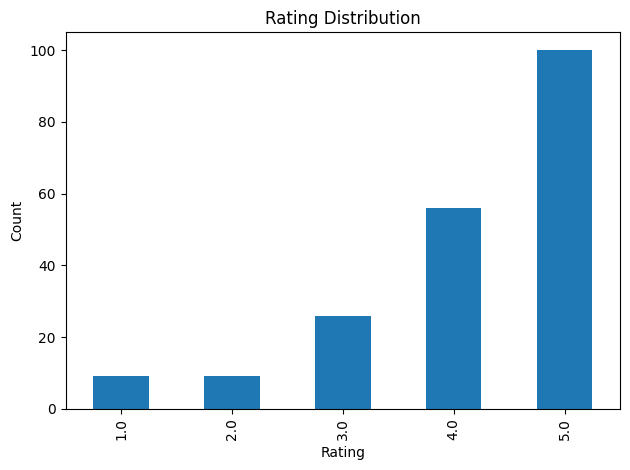

In [7]:
df_reviews["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Review Text Length Histogram

From the chart below, we can see that most of the reviews tend to be on the shorter side, around 250 characters. There are some outliers which run closer to 1750 characters.

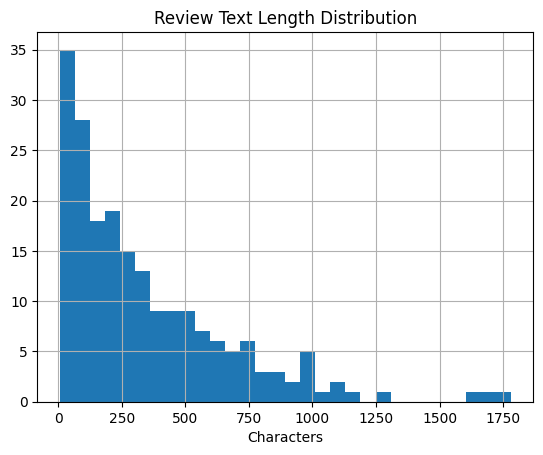

In [8]:
df_reviews["text_len"] = df_reviews["text"].fillna("").apply(len)
df_reviews["text_len"].hist(bins=30)
plt.title("Review Text Length Distribution")
plt.xlabel("Characters")
plt.show()

## Basic EDA (Pricing)

In the below cell, we are looking at the summary statistics of the prices.

**Note:** We use `pd.to_numeric` with `coerce` to ensure price is stored numerically (not as string)

In [25]:
df_meta = pd.DataFrame(meta_raw)
df_meta['price_numeric'] = pd.to_numeric(df_meta['price'], errors='coerce')
print(df_meta.describe())

print(f"Number of products with valid price data: {df_meta['price_numeric'].notna().sum()} out of {len(df_meta)}")

       average_rating  rating_number       price  price_numeric
count      200.000000      200.00000   39.000000      39.000000
mean         3.945000       55.71000   24.478462      24.478462
std          0.803744      177.31806   26.314953      26.314953
min          1.000000        1.00000    2.500000       2.500000
25%          3.600000        4.00000    9.445000       9.445000
50%          4.100000       13.00000   16.950000      16.950000
75%          4.500000       34.00000   26.490000      26.490000
max          5.000000     1960.00000  136.170000     136.170000
Number of products with valid price data: 39 out of 200


### Price Histogram

From the chart below, we can see that most of the items tend to be <$30, although there are some outliers which run closer to $130.

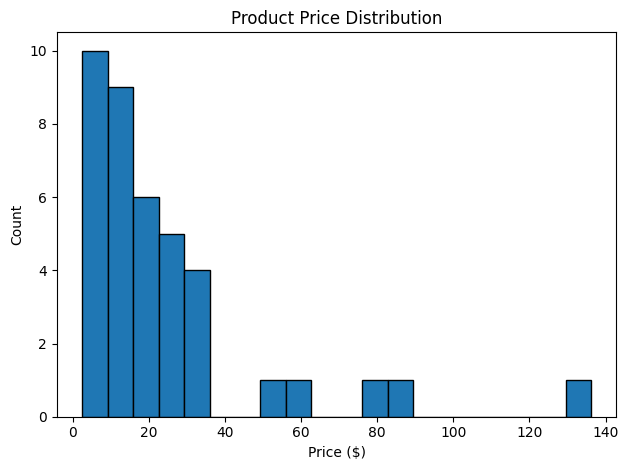

In [21]:
df_meta['price_numeric'].dropna().plot(kind="hist", bins=20, edgecolor='black')
plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Fields Selected for Retrieval & Preprocessing Pipeline

From **reviews**: `text` (user opinion), `rating` (quality signal), `asin` (join key)
- Reviews capture subjective human experiences, and conversational vocabulary that shoppers actually use, which is critical for semantic search success.
- Ratings act as a potential quality filter or reranking weight.
- The join key is used for mapping the product to the correct review.

From **metadata**: `title` (product name), `description` (product details), `features` (key attributes), `price` (useful for filtering if available)
- Title, description and features contain the core, factual representation of the item. They are essential for keyword matching on exact product types and brand names.
- Price is retained for tasks where BM25 and semantic search would struggle (numerical things such as below $20)

Combined into one `combined_text` field per document for indexing.

**Preprocessing decisions:**
- Lowercase everything
- Remove punctuation and numbers using regex (not semantically useful for retrieval)
- No stemming (preserves meaning for semantic search)
- Null or missing text/description fields are safely imputed with empty strings (`""`) 

## Preprocessing Example 

The below cell shows a small demo of the preprocessing.

In [28]:
sample_text = "Wow!! This 100% Argan oil is AMAZING for dry skin... highly recommend it."
print("Original:", sample_text)
print("Cleaned:", " ".join(simple_tokenize(sample_text)))

Original: Wow!! This 100% Argan oil is AMAZING for dry skin... highly recommend it.
Cleaned: wow this 100 argan oil is amazing for dry skin highly recommend it


## Full Corpus Generation

Below, we apply the `build_corpus` function to the entire dataset.

This step reads the full compressed `.jsonl.gz` files, joins the reviews and metadata on `parent_asin`, concatenates the selected text fields into a single `combined_text` document, and serializes the final cleaned corpus to a `.pkl` file for use in our BM25 and Semantic Search models.

In [9]:
reviews_full = load_jsonl_gz("../data/raw/All_Beauty.jsonl.gz")
meta_full = load_jsonl_gz("../data/raw/meta_All_Beauty.jsonl.gz")
corpus = build_corpus(reviews_full, meta_full)

print(f"Full corpus size: {len(corpus)}")
save_pickle(corpus, "../data/processed/corpus.pkl")
print("Corpus saved!")

Full corpus size: 701528
Saved to ../data/processed/corpus.pkl
Corpus saved!


In [30]:
for k, v in corpus[0].items():
    print(f"\t {k}: {str(v)[:100]}")

	 asin: B00YQ6X8EO
	 title: Herbivore - Natural Sea Mist Texturizing Salt Spray (Coconut, 8 oz)
	 review_text: This spray is really nice. It smells really good, goes on really fine, and does the trick. I will sa
	 rating: 5.0
	 price: None
	 combined_text: Herbivore - Natural Sea Mist Texturizing Salt Spray (Coconut, 8 oz) If given the choice, weÕd leave 
